# Import thư viện

In [ ]:
# =============================================
# IMPORT LIBRARIES
# =============================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import math

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Word Cloud
from wordcloud import WordCloud

# Stats
from scipy import stats
from scipy.stats import mannwhitneyu, linregress

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


[nltk_data] Downloading package punkt to C:\Users\HUNG MINH
[nltk_data]     TECHNOLOGY\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\HUNG MINH
[nltk_data]     TECHNOLOGY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HUNG MINH
[nltk_data]     TECHNOLOGY\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load dữ liệu
**Dataset:** [IMDB Dataset of 50K Movie Reviews – Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)  


In [2]:
# =============================================
# LOAD DATA
# =============================================
df = pd.read_csv("../data/raw/IMDB Dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
print(f"\nPhân phối nhãn:\n{df['sentiment'].value_counts()}")
print(f"\n5 dòng đầu:")
df.head()


Shape: (50000, 2)

Các cột: ['review', 'sentiment']

Phân phối nhãn:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

5 dòng đầu:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## NHẬN XÉT - LOAD DỮ LIỆU

---

### Dataset: IMDB Movie Reviews

- Tổng số mẫu: 50,000 reviews  
- Số features: 2 cột  
  - review 
  - sentiment 

---

### Phân phối nhãn

- positive: 25,000 mẫu (50%)  
- negative: 25,000 mẫu (50%)  

---

### Nhận xét

1. Dataset hoàn toàn cân bằng (balanced)  
   → Không cần xử lý imbalance (oversampling / undersampling)

2. Đây là bài toán Binary Classification  
   → Phân loại: positive vs negative

3. Cột review chứa văn bản HTML thô (ví dụ: <"br /">)  
   → Cần được làm sạch (text preprocessing) trước khi xử lý

# Làm sạch dữ liệu ban đầu

**Mục đích:**

Chuẩn hóa văn bản thô trước khi thực hiện EDA nhằm:

- Đảm bảo các thống kê phản ánh đúng nội dung ngôn ngữ  
- Loại bỏ nhiễu từ:
  - HTML (ví dụ: <"br /">)
  - Ký tự đặc biệt

In [3]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """
    Làm sạch văn bản thô:
    - Loại bỏ HTML tags (vd: <br />, <b>...)
    - Loại bỏ ký tự đặc biệt, số
    - Chuẩn hóa khoảng trắng
    - Chuyển về lowercase
    """
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # remove non-alpha
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)            # normalize spaces
    return text

def tokenize(text):
    """Tokenize và loại stopwords"""
    tokens = word_tokenize(clean_text(text))
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

def tokenize_all(text):
    """Tokenize KHÔNG loại stopwords (dùng cho Zipf)"""
    tokens = word_tokenize(clean_text(text))
    return [t for t in tokens if len(t) > 1]

# Thêm cột hỗ trợ
df['cleaned']    = df['review'].apply(clean_text)
df['tokens']     = df['cleaned'].apply(tokenize)
df['tokens_all'] = df['cleaned'].apply(tokenize_all)

df['word_count'] = df['tokens_all'].apply(len)
df['char_count'] = df['cleaned'].apply(len)

print("✅ Làm sạch dữ liệu xong!")
print(df[['word_count','char_count']].describe())

✅ Làm sạch dữ liệu xong!
       word_count  char_count
count  50000.0000  50000.0000
mean     219.6080   1248.3361
std      164.0739    944.4781
min        6.0000     30.0000
25%      119.0000    668.0000
50%      164.0000    925.0000
75%      266.0000   1514.0000
max     2364.0000  13315.0000


# EDA Text

## a) Phân phối độ dài văn bản theo nhãn lớp

### Lý thuyết
Phân tích độ dài văn bản giúp trả lời câu hỏi:  
> "Các review positive và negative có xu hướng dài/ngắn khác nhau không?"

Hai đặc trưng được đo:
- **Số từ (word count):** đếm số token sau khi tách từ.
- **Số ký tự (char count):** đếm tổng ký tự sau khi làm sạch (bao gồm cả khoảng trắng).

### Kiểm định Mann-Whitney U
Vì phân phối độ dài thường **lệch phải** (right-skewed), không thỏa giả định chuẩn,  
ta dùng kiểm định **phi tham số Mann-Whitney U** thay cho t-test.

**Giả thuyết:**
$$H_0: \text{Phân phối độ dài của hai lớp là như nhau}$$
$$H_1: \text{Phân phối độ dài của hai lớp khác nhau}$$

**Thống kê kiểm định:**
$$U = \sum_{i=1}^{n_1} \sum_{j=1}^{n_2} S(x_i, y_j), \quad
S(x,y) = \begin{cases} 1 & x > y \\ 0.5 & x = y \\ 0 & x < y \end{cases}$$

**Quyết định:** Nếu $p\text{-value} < 0.05$, bác bỏ $H_0$ — hai lớp có độ dài khác nhau có ý nghĩa thống kê.

Metric                      Positive        Negative
Word Count mean                221.50          217.72
Word Count median              163.00          165.00
Word Count std                 170.30          157.58
-------------------------------------------------------
Char Count mean               1264.72         1231.96
Char Count median              924.00          927.00
Char Count std                 985.60          901.16
-------------------------------------------------------

[Mann-Whitney U] Word Count
  U = 309412555.00 | p-value = 0.055720 → ❌ Không có ý nghĩa

[Mann-Whitney U] Char Count
  U = 311221398.50 | p-value = 0.428179 → ❌ Không có ý nghĩa


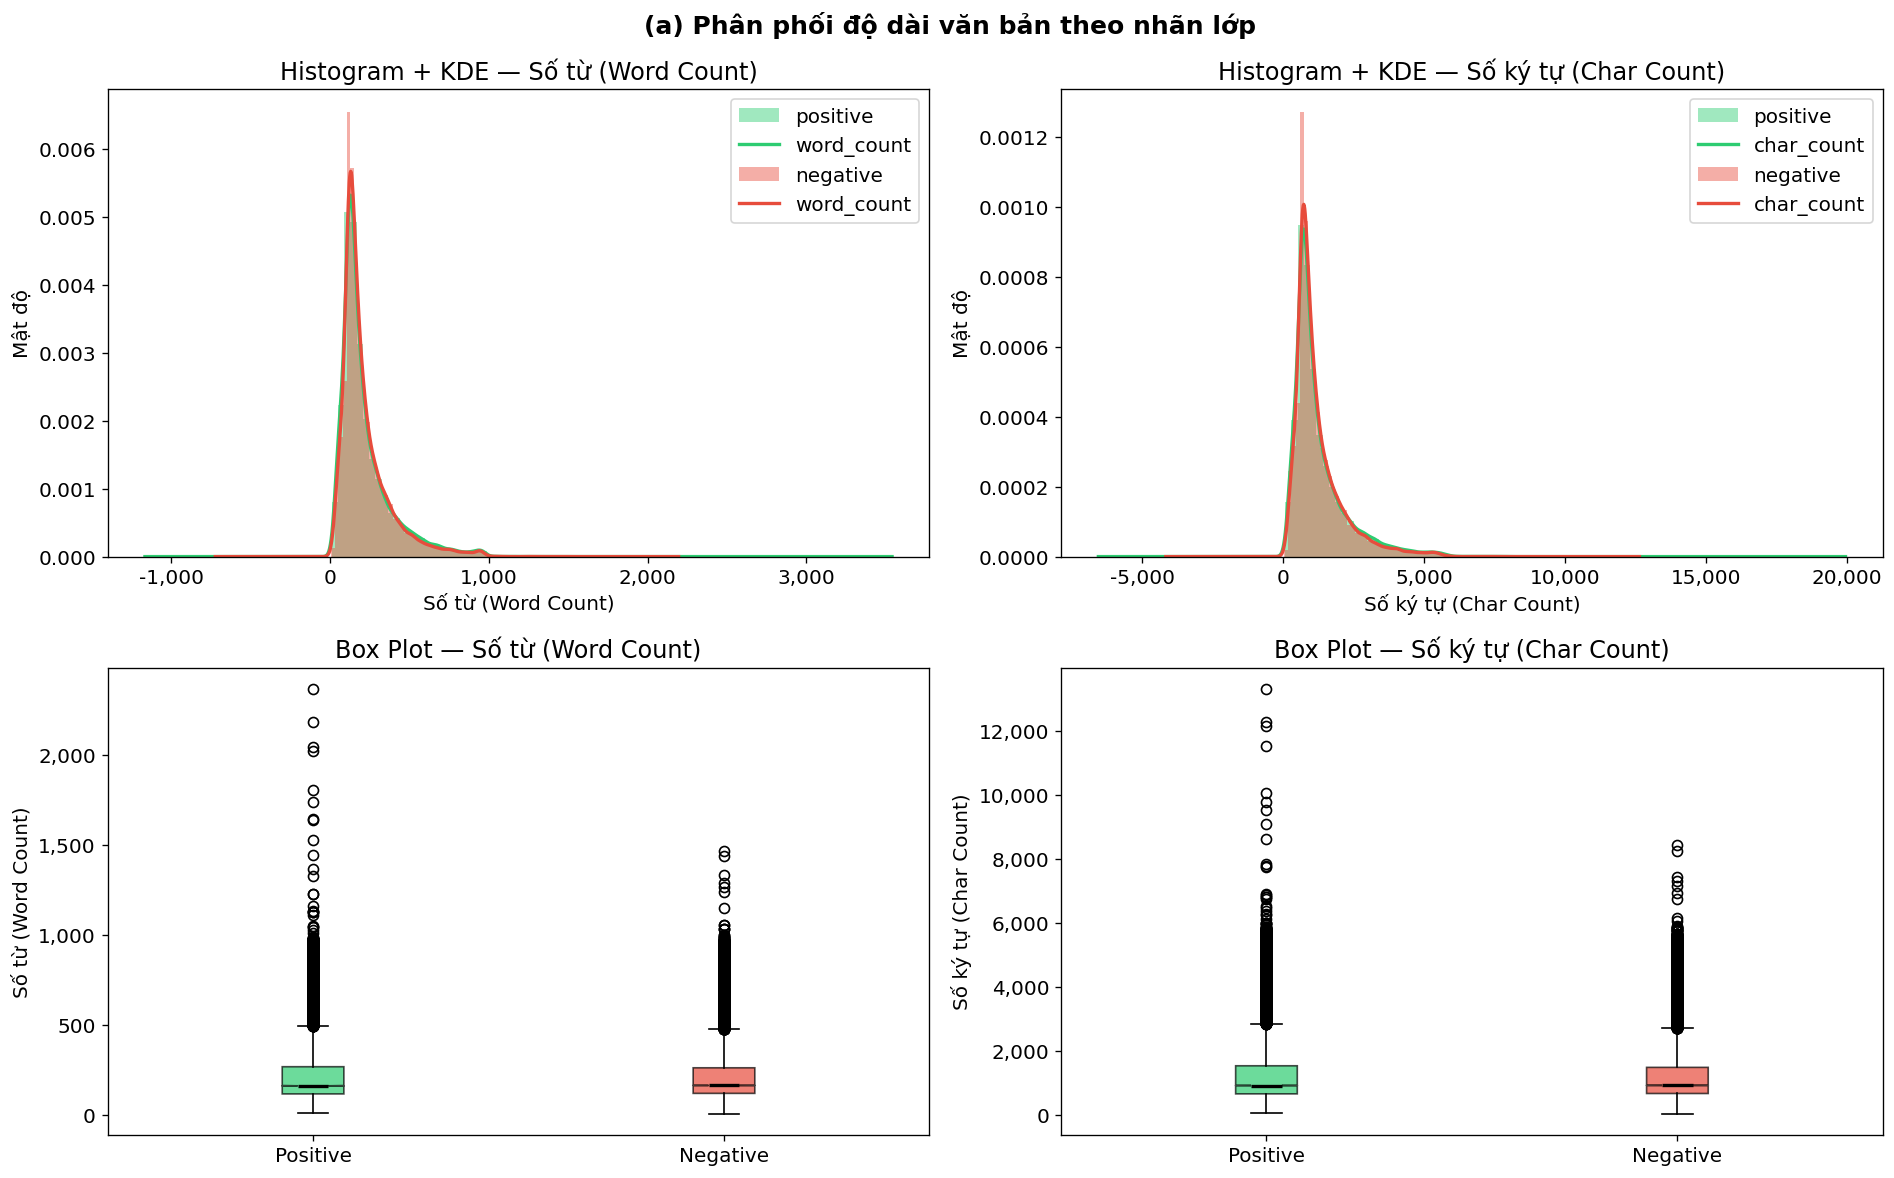

In [4]:
# =============================================
# (a) PHÂN PHỐI ĐỘ DÀI VĂN BẢN
# =============================================
pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

# ---------- Thống kê mô tả ----------
print("=" * 55)
print(f"{'Metric':<20} {'Positive':>15} {'Negative':>15}")
print("=" * 55)
for metric, col in [("Word Count", "word_count"), ("Char Count", "char_count")]:
    for stat_name, fn in [("mean", np.mean), ("median", np.median), ("std", np.std)]:
        print(f"{metric} {stat_name:<10} {fn(pos[col]):>15.2f} {fn(neg[col]):>15.2f}")
    print("-" * 55)

# ---------- Mann-Whitney U ----------
for label, col in [("Word Count", "word_count"), ("Char Count", "char_count")]:
    u_stat, p_val = mannwhitneyu(pos[col], neg[col], alternative='two-sided')
    sig = "✅ Có ý nghĩa thống kê" if p_val < 0.05 else "❌ Không có ý nghĩa"
    print(f"\n[Mann-Whitney U] {label}")
    print(f"  U = {u_stat:.2f} | p-value = {p_val:.6f} → {sig}")

# ---------- Visualization ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("(a) Phân phối độ dài văn bản theo nhãn lớp", fontsize=15, fontweight='bold')

palette = {'positive': '#2ecc71', 'negative': '#e74c3c'}
metrics = [('word_count', 'Số từ (Word Count)'), ('char_count', 'Số ký tự (Char Count)')]

for col_idx, (col, title) in enumerate(metrics):
    # Histogram + KDE
    ax = axes[0, col_idx]
    for sentiment, color in palette.items():
        subset = df[df['sentiment'] == sentiment][col]
        ax.hist(subset, bins=60, alpha=0.45, color=color, label=sentiment, density=True)
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(f'Histogram + KDE — {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Mật độ')
    ax.legend()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Box plot
    ax2 = axes[1, col_idx]
    data_box = [pos[col].values, neg[col].values]
    bp = ax2.boxplot(data_box, patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xticklabels(['Positive', 'Negative'])
    ax2.set_title(f'Box Plot — {title}')
    ax2.set_ylabel(title)
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Phân tích & Nhận xét — Phần (a)

---

#### 1. Thống kê mô tả

| Metric              | Positive | Negative | Chênh lệch        |
|--------------------|----------|----------|-------------------|
| Word Count mean    | 221.50   | 217.72   | +3.78 (+1.7%)     |
| Word Count median  | 163.00   | 165.00   | −2.00             |
| Word Count std     | 170.30   | 157.58   | +12.72            |
| Char Count mean    | 1264.72  | 1231.96  | +32.76 (+2.7%)    |
| Char Count median  | 924.00   | 927.00   | −3.00             |
| Char Count std     | 985.60   | 901.16   | +84.44            |

---

#### 2. Nhận xét từ Histogram + KDE

**Hình dạng phân phối:**

- Cả hai lớp đều có phân phối lệch phải mạnh (right-skewed)  
  → Đỉnh tập trung ở vùng ~100–300 từ  
  → Đuôi kéo dài đến 3,000+ từ (word count) và 15,000+ ký tự (char count)

- Đường KDE của Positive và Negative gần như chồng khít  
  → Không thể phân biệt bằng mắt thường

- Đây là đặc trưng phổ biến của dữ liệu văn bản tự nhiên:  
  → Phần lớn review ngắn (~100–200 từ)  
  → Một số ít review rất dài

**Hàm ý:**

- Mean > Median ở cả hai lớp (ví dụ: 221 > 163)  
  → Xác nhận phân phối lệch phải  
  → Phù hợp sử dụng kiểm định Mann-Whitney U thay vì t-test

---

#### 3. Nhận xét từ Box Plot

- IQR của hai lớp rất tương đồng  
  → Phần lớn review nằm trong khoảng ~50 đến ~500 từ

- Median gần như bằng nhau  
  → Positive = 163, Negative = 165

- Có nhiều outlier ở cả hai lớp  
  → Positive có outlier cao hơn (đến ~2,300 từ, ~13,000 ký tự)

- Positive có độ lệch chuẩn lớn hơn (170 vs 157)  
  → Review tích cực có xu hướng biến động độ dài lớn hơn  
  → Một số trường hợp viết dài hơn để diễn đạt cảm xúc

---

#### 4. Kiểm định Mann-Whitney U

| Kiểm định   | U-statistic | p-value | Kết luận                         |
|------------|-------------|---------|----------------------------------|
| Word Count | 309,412,555 | 0.0557  | Không có ý nghĩa thống kê        |
| Char Count | 311,221,398 | 0.4282  | Không có ý nghĩa thống kê        |

- Cả hai p-value đều > 0.05  
  → Không bác bỏ giả thuyết H₀

- Word Count có p = 0.0557  
  → Gần ngưỡng nhưng chưa đủ mạnh

- Char Count có p = 0.428  
  → Không có khác biệt đáng kể

---

#### 5. Kết luận tổng hợp

- Độ dài văn bản **không phải** là đặc trưng phân biệt giữa review positive và negative

**Hàm ý thực tiễn:**

- Không nên dùng độ dài làm feature đơn lẻ để phân loại
- Mô hình cần tập trung vào:
  - Nội dung ngữ nghĩa (từ vựng)
  - Cấu trúc câu

- Dataset có phân phối độ dài đồng đều giữa hai lớp  
  → Giảm nguy cơ bias khi huấn luyện mô hình

## b) Word Cloud & Top-50 từ phổ biến + Type-Token Ratio (TTR)

### Word Cloud
Word Cloud là biểu đồ trực quan hóa tần suất từ:  
từ càng **xuất hiện nhiều** → hiển thị càng **to** và **đậm**.  
Giúp nhanh chóng nhận ra các từ đặc trưng cho từng nhãn cảm xúc.

### Top-50 từ phổ biến
Đếm tần suất từ (sau khi loại stopwords) và lấy 50 từ cao nhất mỗi lớp.  
Bảng và biểu đồ bar cho thấy sự khác biệt từ vựng giữa positive vs negative.

### Type-Token Ratio (TTR)
TTR đo lường **độ phong phú từ vựng** của một văn bản/tập văn bản:

$$\text{TTR} = \frac{|V|}{N}$$

Trong đó:
- $|V|$ = số từ **duy nhất** (types — vocabulary size)  
- $N$ = tổng số từ (tokens)  
- $\text{TTR} \in (0, 1]$: càng gần 1 → từ vựng càng phong phú, ít lặp lại

**Lưu ý:** TTR nhạy cảm với độ dài văn bản (N lớn → TTR giảm),  
nên thường dùng **MATTR** (Moving Average TTR) hoặc so sánh trên cùng N.

TTR — Positive : 0.024771
TTR — Negative : 0.024512
→ Positive có từ vựng phong phú hơn
       Lớp      TTR Số từ duy nhất (V) Tổng tokens (N)
  Positive  0.02477              74071         2990257
  Negative  0.02451              71081         2899872
Chênh lệch +0.00026                  —               —


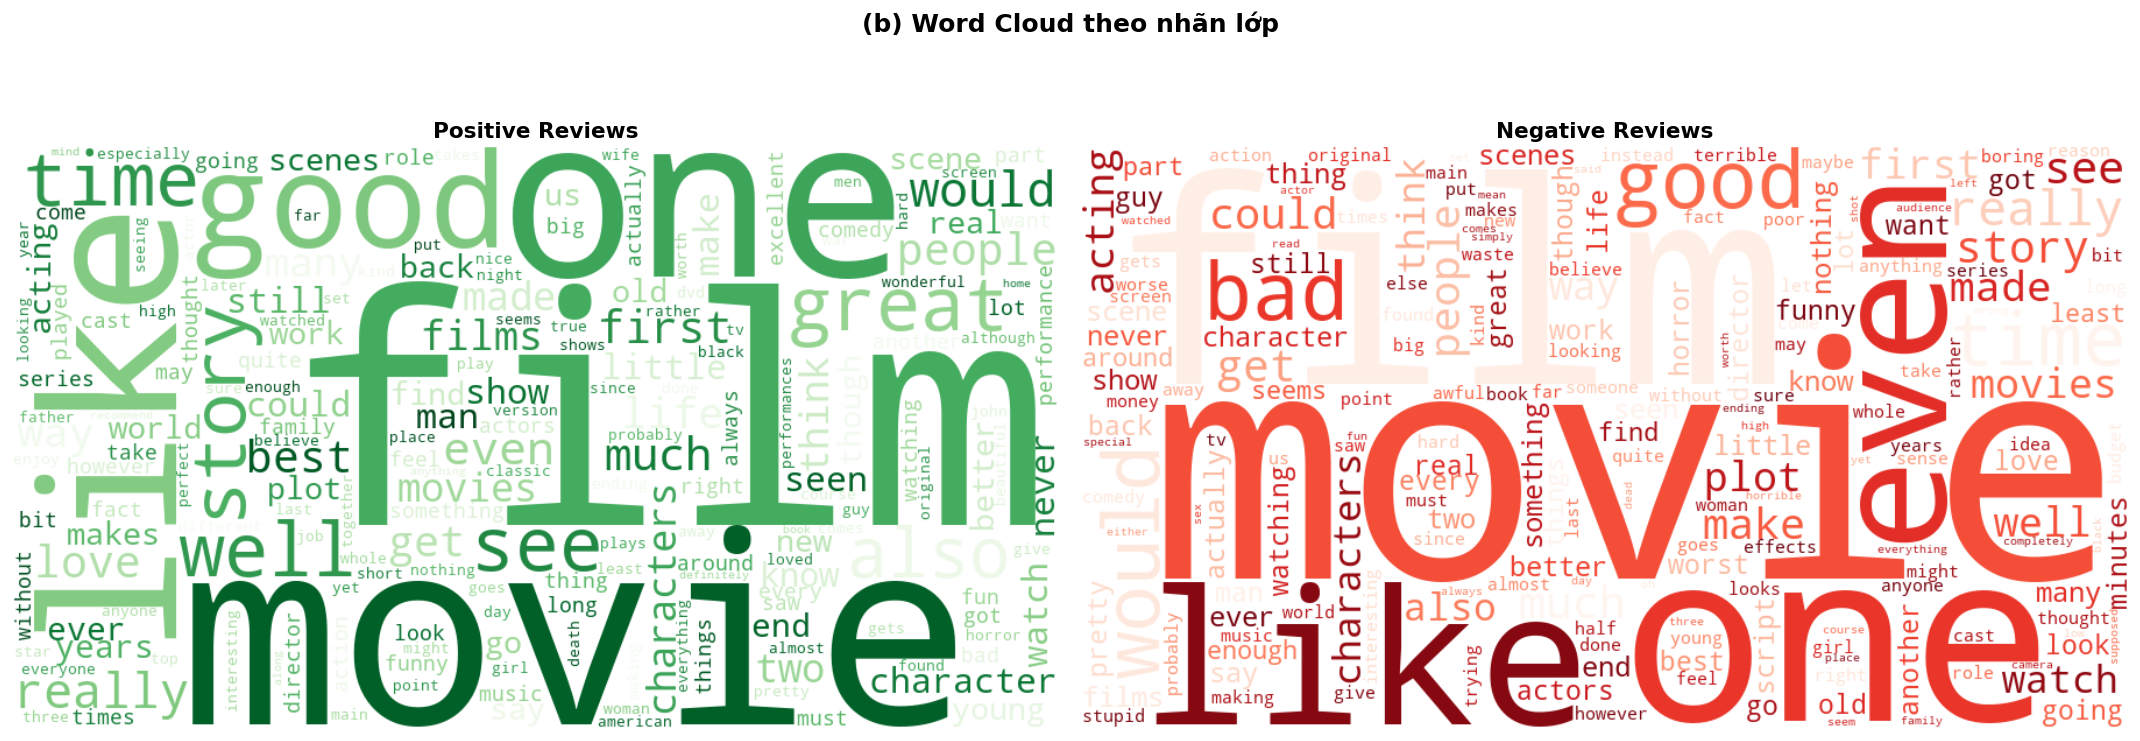

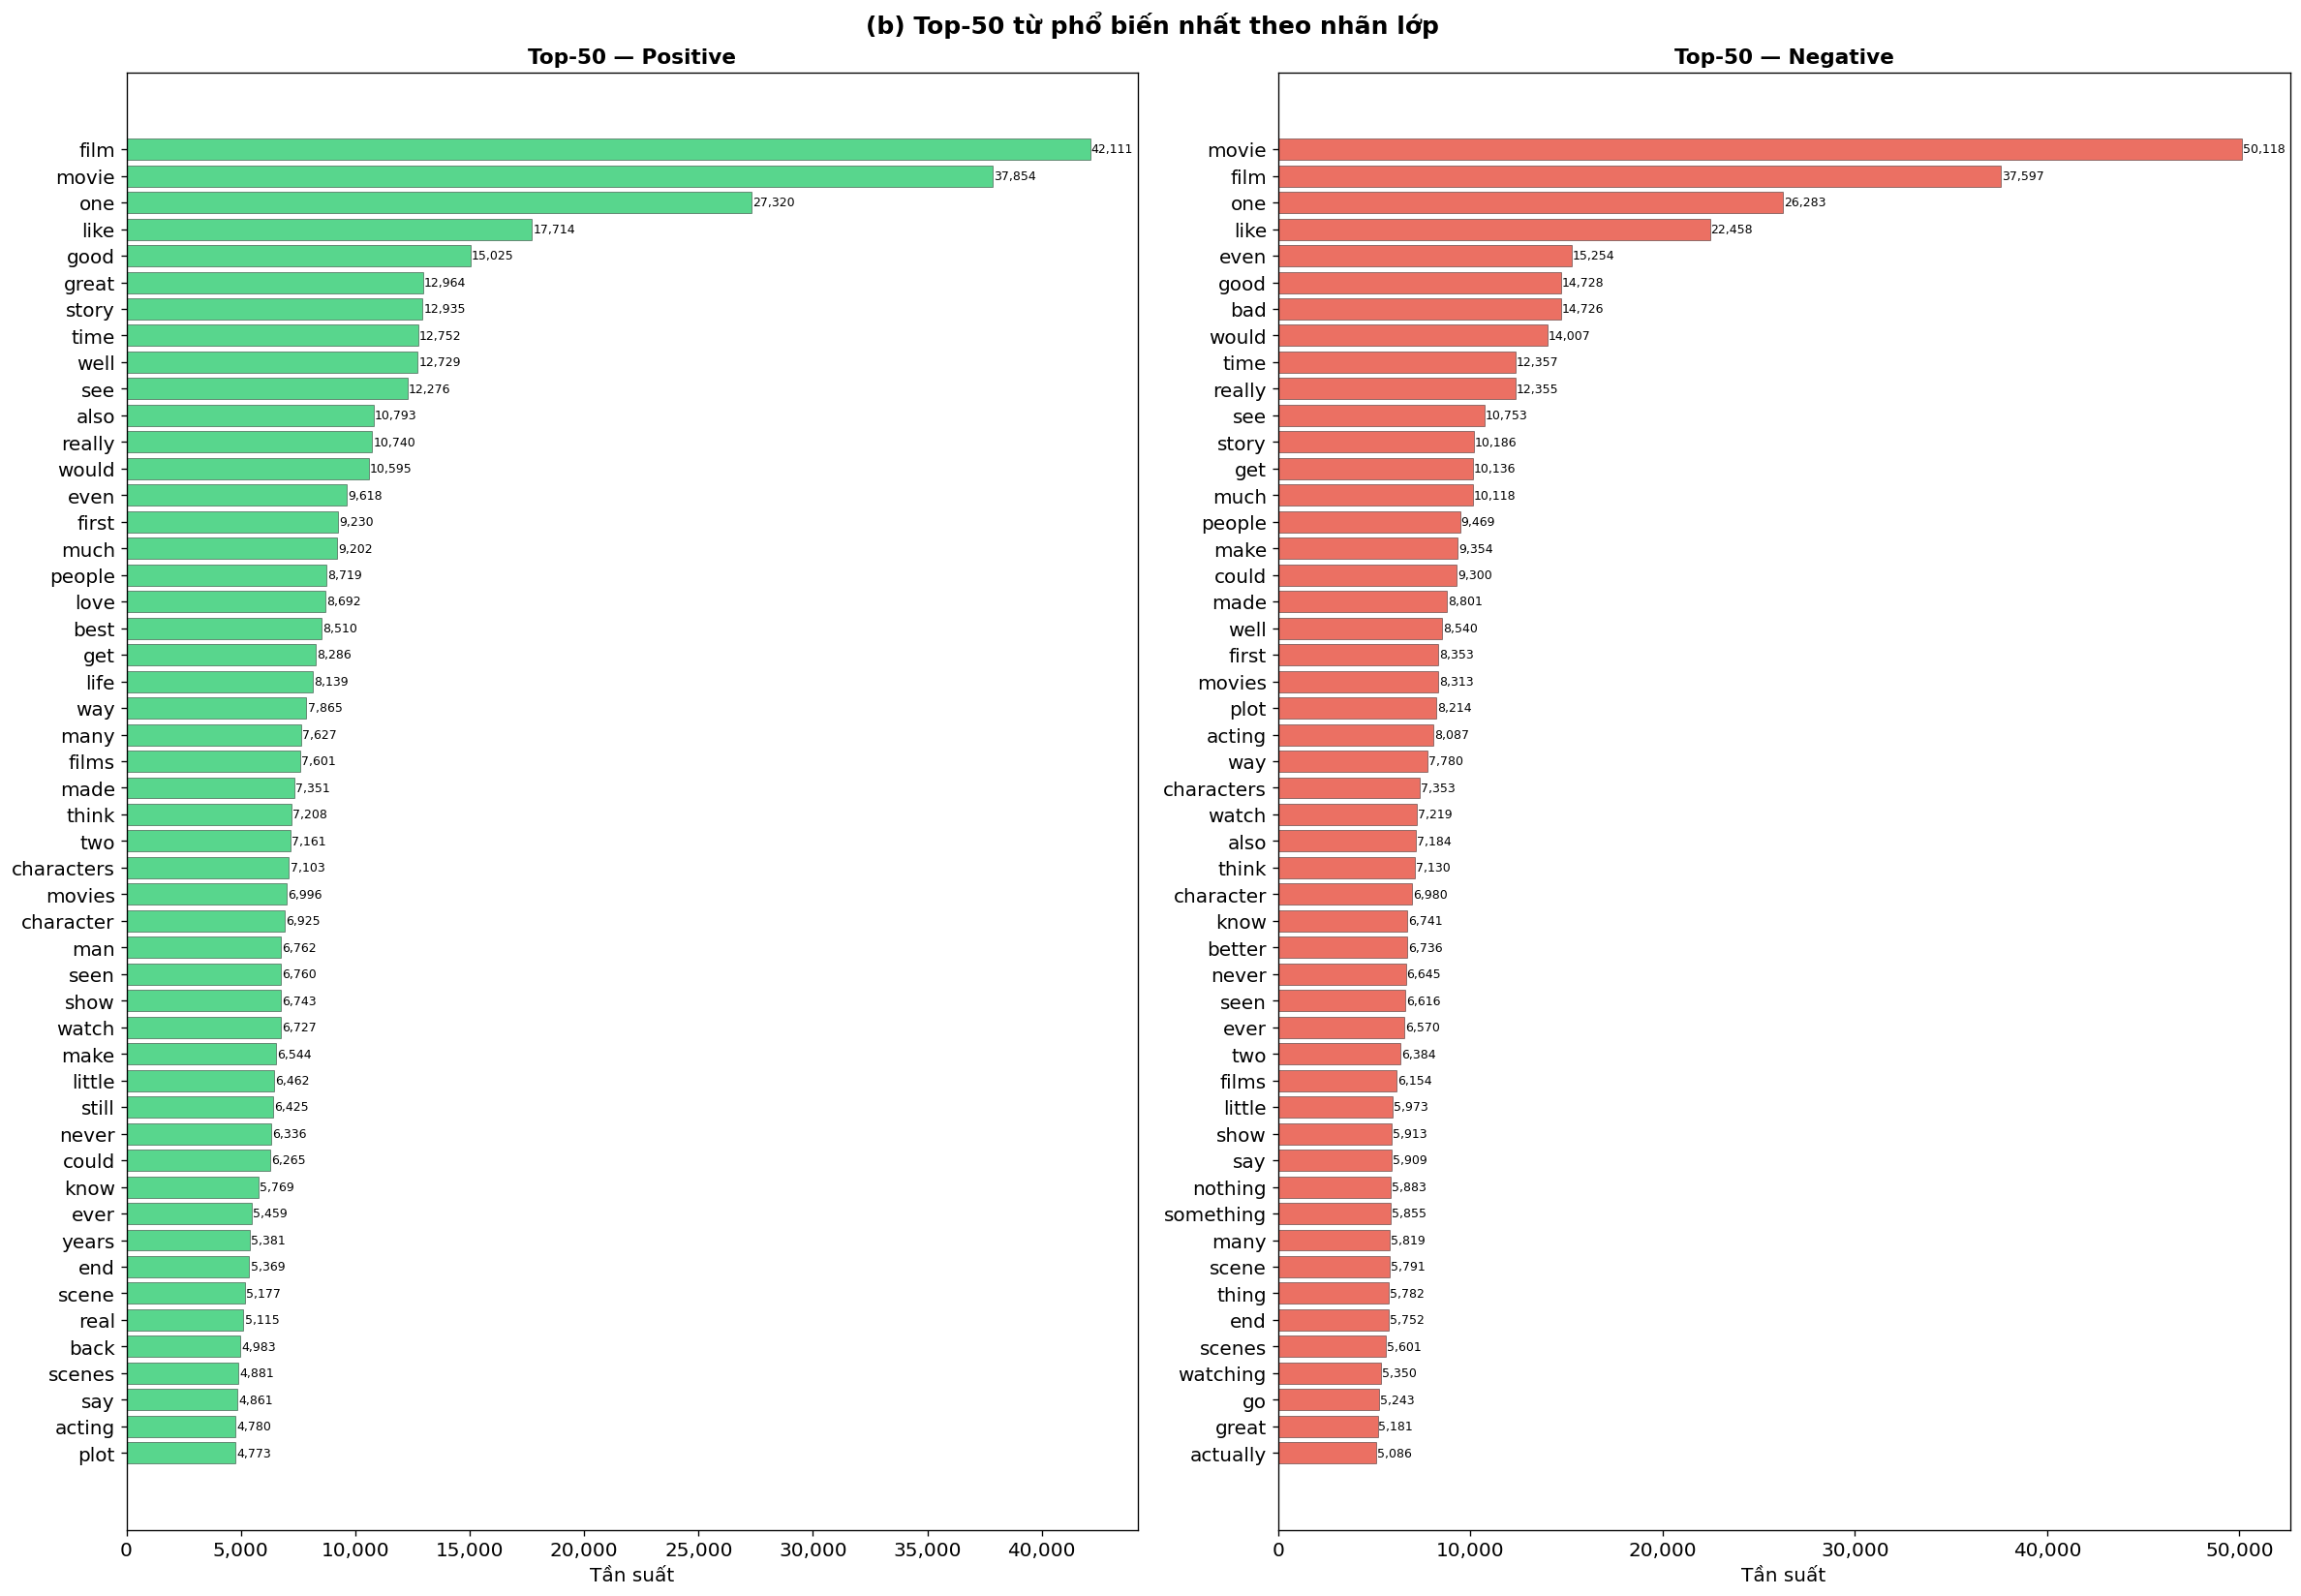


 Bảng Top-50 từ phổ biến:
 Rank Positive Word  Positive Freq Negative Word  Negative Freq
    1          film          42111         movie          50118
    2         movie          37854          film          37597
    3           one          27320           one          26283
    4          like          17714          like          22458
    5          good          15025          even          15254
    6         great          12964          good          14728
    7         story          12935           bad          14726
    8          time          12752         would          14007
    9          well          12729          time          12357
   10           see          12276        really          12355
   11          also          10793           see          10753
   12        really          10740         story          10186
   13         would          10595           get          10136
   14          even           9618          much          10118
   15        

In [5]:
# =============================================
# (b) WORD CLOUD + TOP-50 + TTR
# =============================================

# ---------- Gộp tokens theo class ----------
tokens_pos = [tok for toks in pos['tokens'] for tok in toks]
tokens_neg = [tok for toks in neg['tokens'] for tok in toks]

freq_pos = Counter(tokens_pos)
freq_neg = Counter(tokens_neg)

top50_pos = freq_pos.most_common(50)
top50_neg = freq_neg.most_common(50)

# ---------- TTR ----------
def compute_ttr(token_list):
    N = len(token_list)
    V = len(set(token_list))
    return V / N if N > 0 else 0

ttr_pos = compute_ttr(tokens_pos)
ttr_neg = compute_ttr(tokens_neg)
print(f"TTR — Positive : {ttr_pos:.6f}")
print(f"TTR — Negative : {ttr_neg:.6f}")
print(f"→ {'Positive' if ttr_pos > ttr_neg else 'Negative'} có từ vựng phong phú hơn")
ttr_df = pd.DataFrame({
    'Lớp'              : ['Positive', 'Negative', 'Chênh lệch'],
    'TTR'              : [f'{ttr_pos:.5f}', f'{ttr_neg:.5f}', f'{ttr_pos - ttr_neg:+.5f}'],
    'Số từ duy nhất (V)': [len(set(tokens_pos)), len(set(tokens_neg)), '—'],
    'Tổng tokens (N)'  : [len(tokens_pos), len(tokens_neg), '—'],
})
print(ttr_df.to_string(index=False))
# ---------- Word Cloud ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("(b) Word Cloud theo nhãn lớp", fontsize=15, fontweight='bold')

for ax, (freq, label, cmap) in zip(axes, [
    (freq_pos, 'Positive', 'Greens'),
    (freq_neg, 'Negative', 'Reds')
]):
    wc = WordCloud(
        width=900, height=500,
        background_color='white',
        colormap=cmap,
        max_words=200,
        collocations=False
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label} Reviews', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# ---------- Top-50 Bar chart ----------
fig, axes = plt.subplots(1, 2, figsize=(20, 14))
fig.suptitle("(b) Top-50 từ phổ biến nhất theo nhãn lớp", fontsize=15, fontweight='bold')

for ax, (top50, label, color) in zip(axes, [
    (top50_pos, 'Positive', '#2ecc71'),
    (top50_neg, 'Negative', '#e74c3c')
]):
    words, counts = zip(*top50)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top-50 — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tần suất')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for i, (w, c) in enumerate(zip(words[::-1], counts[::-1])):
        ax.text(c + 50, i, f'{c:,}', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

# ---------- Bảng Top-50 ----------
df_top50 = pd.DataFrame({
    'Rank': range(1, 51),
    'Positive Word': [w for w, _ in top50_pos],
    'Positive Freq': [c for _, c in top50_pos],
    'Negative Word': [w for w, _ in top50_neg],
    'Negative Freq': [c for _, c in top50_neg],
})
print("\n Bảng Top-50 từ phổ biến:")
print(df_top50.to_string(index=False))

### Phân tích & Nhận xét — Phần (b)

---

#### 1. Type-Token Ratio (TTR)

| Lớp      | TTR     | Số từ duy nhất (V) | Tổng tokens (N) |
|----------|---------|--------------------|-----------------|
| Positive | 0.02477 | 74071              | 2990257         |
| Negative | 0.02451 | 71081              | 2899872         |
| Chênh lệch | +0.00026 | Positive phong phú hơn | — |

**Nhận xét:**

- Cả hai lớp có TTR rất thấp (~0.0247), điều này bình thường với corpus lớn  
  → Khi số lượng tokens (N) tăng, từ bị lặp lại nhiều → TTR giảm

- Positive cao hơn Negative một chút  
  → Gợi ý vốn từ đa dạng hơn (mô tả nhiều khía cạnh như story, acting, music, ...)

- Tuy nhiên chênh lệch rất nhỏ (< 0.0003)  
  → Không đủ mạnh để kết luận  
  → Nên dùng thêm:
  - MATTR (Moving-Average TTR)  
  - Hoặc chuẩn hóa theo N

---

#### 2. Word Cloud

**Quan sát chung:**

- Cả hai lớp đều bị chi phối bởi từ domain chung:  
  film, movie, one, like

- Word Cloud hai lớp nhìn khá giống nhau ở tầng từ phổ biến  
  → Khác biệt nằm ở lớp từ cảm xúc (ít phổ biến hơn)

---

**Positive Reviews:**

- Từ nổi bật:  
  great, good, best, love, well, story, life, wonderful, excellent, beautiful

- Đặc điểm:
  - Từ mang sắc thái tích cực rõ ràng: great, love, best, excellent
  - Có nhiều từ mô tả chiều sâu nội dung:  
    story, character, life, performance

---

**Negative Reviews:**

- Từ nổi bật:  
  bad, even, really, never, nothing, plot, acting, stupid, awful, terrible, boring, waste

- Đặc điểm:
  - "even" xuất hiện nhiều  
    → Thường trong cấu trúc phủ định: *"not even good"*, *"can't even..."*

  - Nhóm từ tiêu cực rõ ràng:  
    bad, awful, terrible, boring, stupid

  - "would" xuất hiện nhiều  
    → Câu tiếc nuối: *"wouldn't watch again"*, *"could have been better"*

---

#### 3. Top-50 từ phổ biến

**Từ chung (overlap cao):** film, movie, one, like, good, time, see, story, would, really,
also, even, first, much, people, well, get, made, characters,
show, watch, think, two, films, little, never, could, know,
scene, say, acting, plot, way


→ Khoảng 33/50 từ trùng nhau  
→ Do cùng domain (review phim)

---

**Từ đặc trưng — Positive:**

| Từ    | Tần suất | Ý nghĩa |
|-------|---------|--------|
| great | 12,964  | Đánh giá xuất sắc |
| best  | 8,510   | Tuyệt vời nhất |
| love  | 8,692   | Yêu thích |
| life  | 8,139   | Chiều sâu cảm xúc |
| man   | 6,762   | Nhân vật |
| seen  | 6,760   | "best I've seen" |
| years | 5,381   | So sánh theo thời gian |
| end   | 5,369   | Kết phim |
| real  | 5,115   | Chân thực |
| back  | 4,983   | Xem lại |

---

**Từ đặc trưng — Negative:**

| Từ        | Tần suất | Ý nghĩa |
|-----------|---------|--------|
| bad       | 14,726  | Tiêu cực trực tiếp |
| even      | 15,254  | Phủ định mạnh |
| make      | 9,354   | "doesn't make sense" |
| nothing   | 5,883   | Không có giá trị |
| something | 5,855   | Có vấn đề |
| better    | 6,736   | So sánh tiêu cực |
| never     | 6,645   | Phủ định tuyệt đối |
| go        | 5,243   | "don't go see it" |
| actually  | 5,086   | Nhấn mạnh tiêu cực |
| watching  | 5,350   | "not worth watching" |

---

**Quan sát đặc biệt:**

- "movie" là từ #1 ở Negative nhưng thấp hơn ở Positive  
- "film" là từ #1 ở Positive  

→ Gợi ý:
- Positive: dùng từ mang tính "nghệ thuật" hơn (film)
- Negative: dùng từ phổ thông hơn (movie)

---

#### 4. Kết luận tổng hợp

- TTR gần như giống nhau  
  → Độ phong phú từ vựng không phải yếu tố phân biệt chính

- Sự khác biệt nằm ở **từ vựng cảm xúc**:
  - Positive: great, love, best, life
  - Negative: bad, even, never, nothing, worse

---

**Hàm ý cho mô hình:**

- Không nên dùng toàn bộ từ vựng raw  
- Nên:
  - Dùng TF-IDF có chọn lọc  
  - Loại bỏ từ chung (film, movie, one, ...)

- Nên sử dụng n-grams:
  - bigram: not good, very bad
  - trigram: waste of time, highly recommend

→ Giúp nắm bắt ngữ cảnh phủ định, rất quan trọng trong sentiment analysis


## c) Phân tích phân phối Zipf

### Định luật Zipf
Định luật Zipf (George Kingsley Zipf, 1949) phát biểu:

> Trong ngôn ngữ tự nhiên, tần suất của một từ **tỉ lệ nghịch** với hạng (rank) của nó.

$$f(r) = \frac{C}{r^{\alpha}}$$

Trong đó:
- $f(r)$ = tần suất của từ ở hạng $r$
- $r$ = hạng từ (rank), từ phổ biến nhất có $r=1$
- $\alpha \approx 1$ (hệ số Zipf lý tưởng)
- $C$ = hằng số chuẩn hóa

### Log-log plot
Lấy $\log$ hai vế:

$$\log f(r) = \log C - \alpha \cdot \log r$$

Đây là phương trình **đường thẳng** trên không gian log-log với **độ dốc** $= -\alpha$.  
Nếu dữ liệu thực tế gần với đường thẳng này → tuân theo định luật Zipf.

### Đánh giá mức độ tuân theo
- Dùng **hồi quy tuyến tính (OLS)** trên log-log để ước lượng $\hat{\alpha}$ và $R^2$
- $|\hat{\alpha} - 1|$ càng nhỏ và $R^2$ càng gần 1 → càng tuân theo Zipf

Metric                         Positive           Negative
α (Zipf exponent)                1.6116
R²                               0.9645
p-value (OLS)                  0.000000
------------------------------------------------------------
α (Zipf exponent)                1.5994
R²                               0.9680
p-value (OLS)                  0.000000
------------------------------------------------------------

 Tóm tắt:
  positive  : α = 1.6116 | R² = 0.9645 | |α-1| = 0.6116
  negative  : α = 1.5994 | R² = 0.9680 | |α-1| = 0.5994


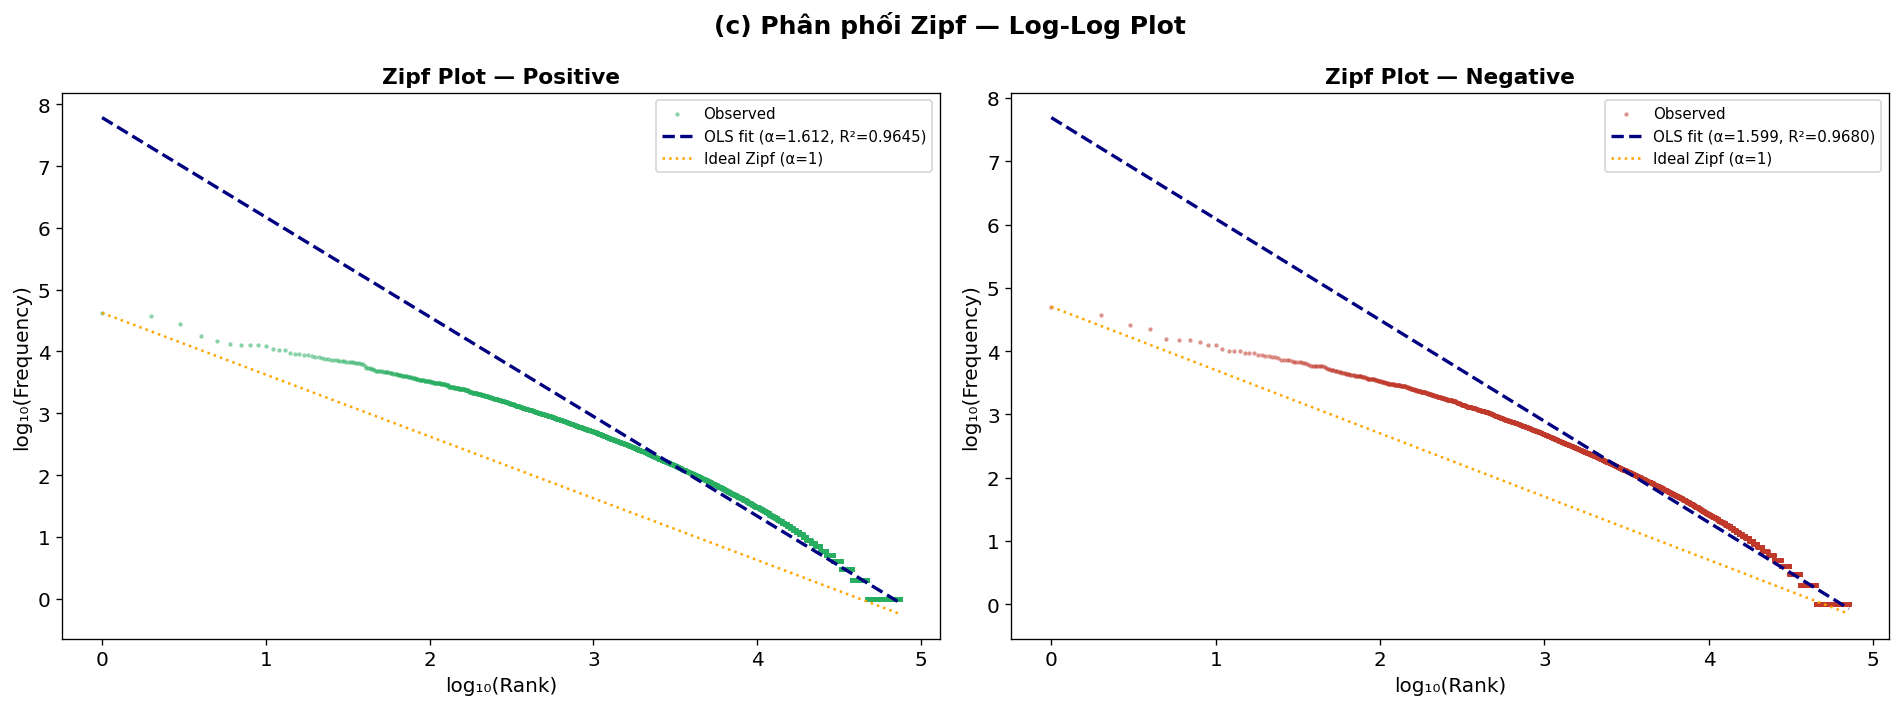

In [6]:
# =============================================
# (c) PHÂN TÍCH PHÂN PHỐI ZIPF
# =============================================

def zipf_analysis(token_list, label, color, ax):
    freq = Counter(token_list)
    # Sắp xếp giảm dần theo tần suất
    sorted_freq = sorted(freq.values(), reverse=True)
    ranks  = np.arange(1, len(sorted_freq) + 1)
    counts = np.array(sorted_freq)

    log_r = np.log10(ranks)
    log_f = np.log10(counts)

    # OLS trên log-log
    slope, intercept, r_value, p_value, std_err = linregress(log_r, log_f)

    # Zipf lý tưởng (alpha = 1)
    ideal_zipf = np.log10(counts[0]) - log_r  # log C - 1*log(r)

    # Plot
    ax.scatter(log_r, log_f, s=3, alpha=0.4, color=color, label='Observed')
    ax.plot(log_r, intercept + slope * log_r, color='navy',
            linewidth=2, linestyle='--', label=f'OLS fit (α={-slope:.3f}, R²={r_value**2:.4f})')
    ax.plot(log_r, ideal_zipf, color='orange',
            linewidth=1.5, linestyle=':', label='Ideal Zipf (α=1)')

    ax.set_title(f'Zipf Plot — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('log₁₀(Rank)')
    ax.set_ylabel('log₁₀(Frequency)')
    ax.legend(fontsize=9)

    return slope, r_value**2, p_value

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("(c) Phân phối Zipf — Log-Log Plot", fontsize=15, fontweight='bold')

print("=" * 60)
print(f"{'Metric':<20} {'Positive':>18} {'Negative':>18}")
print("=" * 60)

results = {}
for ax, (token_list, label, color, key) in zip(axes, [
    (tokens_pos, 'Positive', '#27ae60', 'positive'),
    (tokens_neg, 'Negative', '#c0392b', 'negative'),
]):
    slope, r2, pval = zipf_analysis(token_list, label, color, ax)
    results[key] = {'alpha': -slope, 'R2': r2}
    print(f"α (Zipf exponent)    {results['positive']['alpha'] if key=='positive' else results['negative']['alpha']:>18.4f}")
    print(f"R²                   {r2:>18.4f}")
    print(f"p-value (OLS)        {pval:>18.6f}")
    print("-" * 60)

# In lại gọn
print("\n Tóm tắt:")
for k, v in results.items():
    diff = abs(v['alpha'] - 1)
    print(f"  {k:10s}: α = {v['alpha']:.4f} | R² = {v['R2']:.4f} | |α-1| = {diff:.4f}")

plt.tight_layout()
plt.show()

### Phân tích & Nhận xét — Phần (c): Phân phối Zipf

---

#### 1. Bảng tóm tắt kết quả

| Metric              | Positive | Negative |
|--------------------|----------|----------|
| α (Zipf exponent)  | 1.6116   | 1.5994   |
| R²                 | 0.9645   | 0.9680   |
| p-value (OLS)      | 0.000000 | 0.000000 |
| \|α − 1\|          | 0.6116   | 0.5994   |

---

#### 2. Nhận xét từ Log-Log Plot

##### Hình dạng tổng thể

- Cả hai đồ thị có xu hướng tuyến tính trên không gian log-log  
  → Xác nhận phân phối dạng power-law (Zipf)

- Đường OLS fit khớp tốt với dữ liệu  
  → R² ≈ 0.96–0.97

- p-value ≈ 0  
  → Mô hình có ý nghĩa thống kê rất cao

---

##### Ba vùng trên đồ thị

**Vùng 1 — Rank thấp (log₁₀(Rank) < 1, rank 1–10):**

- Điểm dữ liệu nằm dưới đường OLS và Zipf lý tưởng  
- Hiện tượng *head deflection* (đầu bẹt)

**Nguyên nhân:**
- Các từ phổ biến như film, movie, one chưa đạt khoảng cách tần suất lý tưởng

---

**Vùng 2 — Rank trung bình (1 ≤ log₁₀(Rank) ≤ 3.5, rank 10–3,000):**

- Dữ liệu bám sát đường OLS nhất  
- Zipf hoạt động tốt nhất tại đây

**Ví dụ từ:**
- story, character, acting, plot

---

**Vùng 3 — Rank cao (log₁₀(Rank) > 3.5, rank > 3,000):**

- Dữ liệu cong xuống dưới đường OLS  
- Hiện tượng *tail truncation*

**Giải thích:**
- Từ hiếm (xuất hiện 1–2 lần) giảm nhanh hơn mô hình lý thuyết  
- Do corpus hữu hạn

---

#### 3. Phân tích hệ số α

So sánh với Zipf lý tưởng (α = 1):

- |α_positive − 1| = 0.6116  
- |α_negative − 1| = 0.5994  

**Nhận xét:**

- α > 1  
  → Tần suất giảm nhanh hơn Zipf cổ điển  
  → Đuôi phân phối mỏng hơn

---

##### Nguyên nhân α ≠ 1

| Nguyên nhân         | Giải thích |
|--------------------|-----------|
| Corpus chuyên biệt | Dữ liệu IMDB chỉ xoay quanh phim |
| Tiền xử lý         | Loại stopwords làm mất các từ cực phổ biến |
| Corpus hữu hạn     | 50,000 reviews chưa đủ lớn |

---

##### So sánh giữa hai lớp

- α(Positive) = 1.6116 > α(Negative) = 1.5994  
  → Positive có đuôi mỏng hơn một chút

- R²(Negative) > R²(Positive)  
  → Negative tuân theo Zipf tốt hơn một chút

- Tuy nhiên:
  - Δα ≈ 0.012  
  - ΔR² ≈ 0.004  

→ Khác biệt rất nhỏ → hai lớp có cấu trúc tương đồng

---

#### 4. Kết luận tổng hợp

- Cả hai lớp tuân theo phân phối Zipf (power-law)  
  → R² cao (~0.96–0.97)

- α ≈ 1.6 (không phải 1.0)  
  → Corpus có đuôi mỏng hơn ngôn ngữ tự nhiên tổng quát

---

#### Hàm ý cho Data Mining

- Một số ít từ chiếm phần lớn tần suất  
  → Giải thích tại sao TF-IDF hiệu quả:
  - Giảm trọng số từ phổ biến (film, movie)
  - Tăng trọng số từ đặc trưng (great, terrible)

- Vùng rank trung bình (10–3,000) là quan trọng nhất  
  → Cân bằng giữa phổ biến và tính phân biệt

- Nên giới hạn vocabulary:
  - Ví dụ: top 5,000–10,000 từ  
  → Loại bỏ vùng đuôi nhiễu (rank rất cao)